### 1 Creating and Manipulating Arrays

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x_1d = np.linspace(-2, 2, 100)
y_1d = np.linspace(-2, 2, 100)

x, y = np.meshgrid(x_1d, y_1d)

print(x.shape)  # Should be (100, 100)
print(y.shape)  # Should be (100, 100)

(100, 100)
(100, 100)


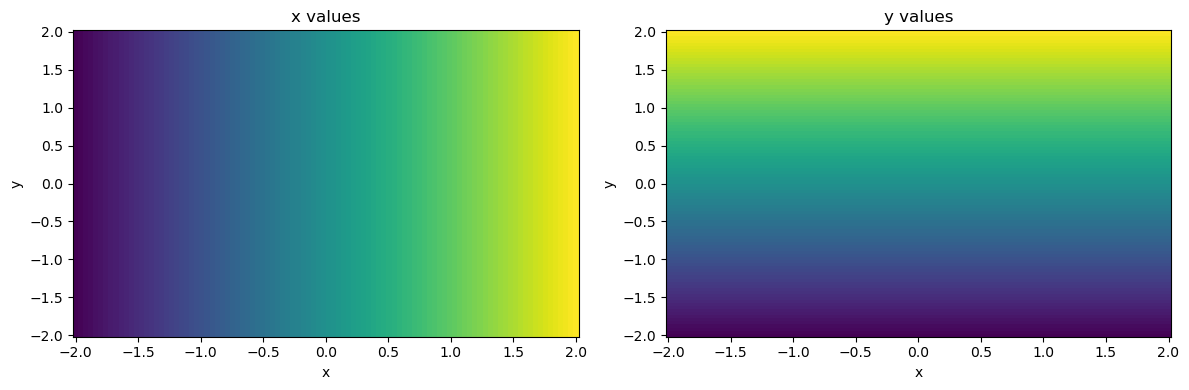

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pcolormesh(x_1d, y_1d, x)
axes[0].set_title("x values")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

axes[1].pcolormesh(x_1d, y_1d, y)
axes[1].set_title("y values")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

plt.tight_layout()
plt.show()

In [4]:
r = np.sqrt(x**2 + y**2)
theta = np.arctan2(y, x)  # note: arctan2 takes (y, x), not (x, y)!

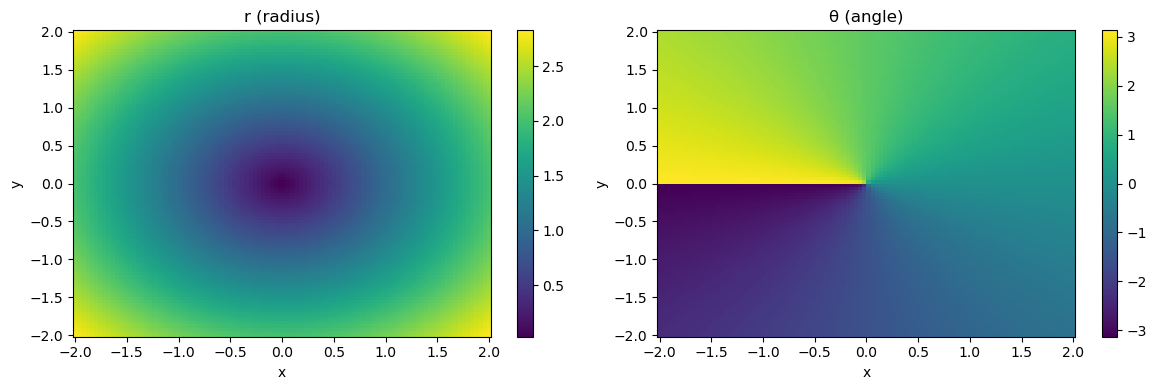

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

mesh0 = axes[0].pcolormesh(x_1d, y_1d, r)
axes[0].set_title("r (radius)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(mesh0, ax=axes[0])

mesh1 = axes[1].pcolormesh(x_1d, y_1d, theta)
axes[1].set_title("θ (angle)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.colorbar(mesh1, ax=axes[1])

plt.tight_layout()
plt.show()

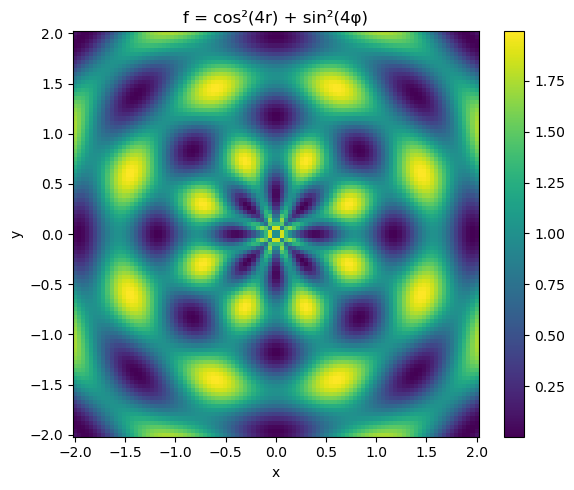

In [6]:
f = np.cos(4 * r)**2 + np.sin(4 * theta)**2

fig, ax = plt.subplots(figsize=(6, 5))

mesh = ax.pcolormesh(x_1d, y_1d, f)
ax.set_title("f = cos²(4r) + sin²(4φ)")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.colorbar(mesh, ax=ax)

plt.tight_layout()
plt.show()

### Part 2: Analyze ARGO Data

In [7]:
import pooch

url = "https://www.ldeo.columbia.edu/~danielmw/float_data.zip"
files = pooch.retrieve(url, processor=pooch.Unzip(), 
                       known_hash="2a703c720302c682f1662181d329c9f22f9f10e1539dc2d6082160a469165009")
print(files)

Unzipping contents of '/home/ld3228/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip' to '/home/ld3228/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip'


['/home/ld3228/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/date.npy', '/home/ld3228/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/T.npy', '/home/ld3228/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/S.npy', '/home/ld3228/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/P.npy', '/home/ld3228/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/levels.npy', '/home/ld3228/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lon.npy', '/home/ld3228/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lat.npy']


In [9]:
def get_file(name):
    return [f for f in files if f.endswith(name)][0]

T     = np.load(get_file('T.npy'))
S     = np.load(get_file('S.npy'))
P     = np.load(get_file('P.npy'))
date  = np.load(get_file('date.npy'))
lat   = np.load(get_file('lat.npy'))
lon   = np.load(get_file('lon.npy'))
level = np.load(get_file('levels.npy'))

In [10]:
print("T shape:     ", T.shape)
print("S shape:     ", S.shape)
print("P shape:     ", P.shape)
print("date shape:  ", date.shape)
print("lat shape:   ", lat.shape)
print("lon shape:   ", lon.shape)
print("level shape: ", level.shape)

T shape:      (78, 75)
S shape:      (78, 75)
P shape:      (78, 75)
date shape:   (75,)
lat shape:    (75,)
lon shape:    (75,)
level shape:  (78,)


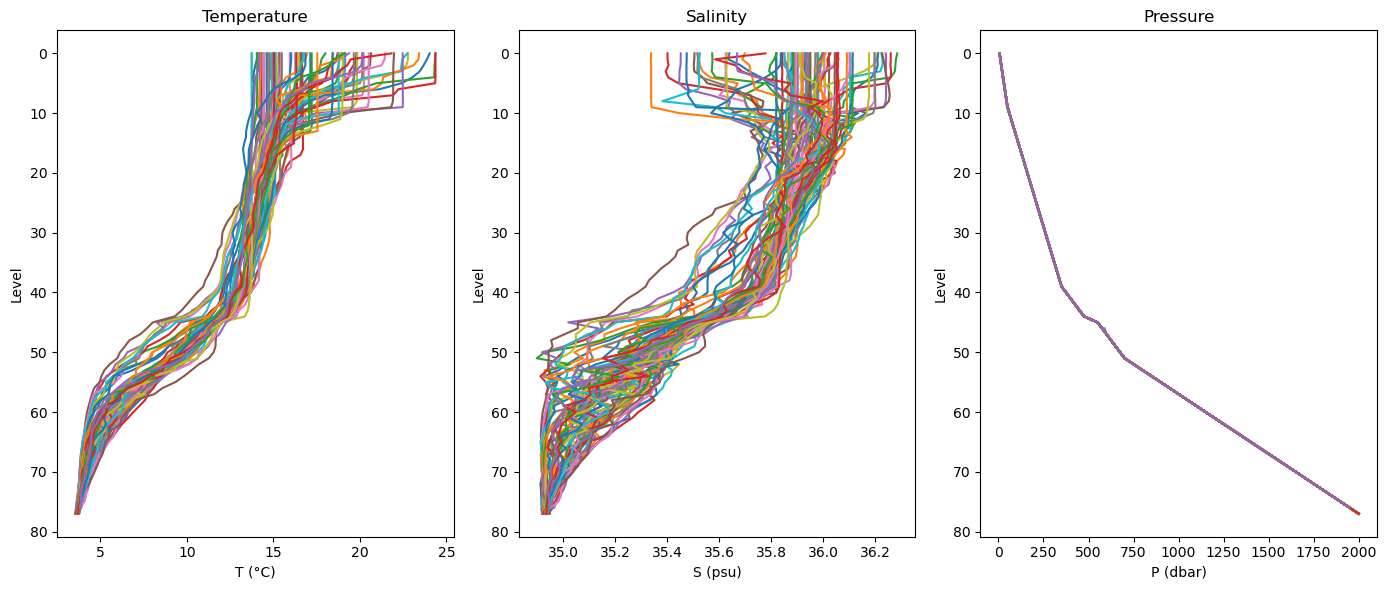

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

# Temperature
for i in range(T.shape[1]):
    axes[0].plot(T[:, i], level)
axes[0].set_title("Temperature")
axes[0].set_xlabel("T (°C)")
axes[0].set_ylabel("Level")
axes[0].invert_yaxis()  # depth increases downward

# Salinity
for i in range(S.shape[1]):
    axes[1].plot(S[:, i], level)
axes[1].set_title("Salinity")
axes[1].set_xlabel("S (psu)")
axes[1].set_ylabel("Level")
axes[1].invert_yaxis()

# Pressure
for i in range(P.shape[1]):
    axes[2].plot(P[:, i], level)
axes[2].set_title("Pressure")
axes[2].set_xlabel("P (dbar)")
axes[2].set_ylabel("Level")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

In [12]:
T_mean = np.mean(T, axis=1)
T_std  = np.std(T, axis=1)

S_mean = np.mean(S, axis=1)
S_std  = np.std(S, axis=1)

P_mean = np.mean(P, axis=1)
P_std  = np.std(P, axis=1)

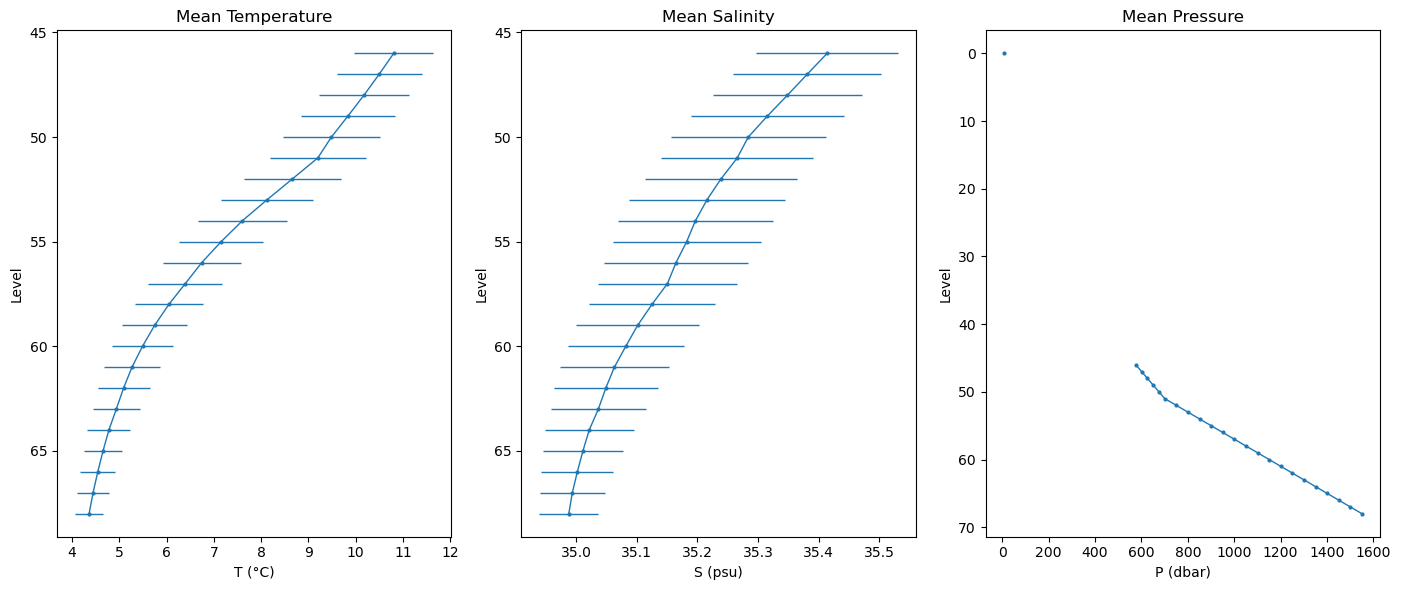

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

# Temperature
axes[0].errorbar(T_mean, level, xerr=T_std, fmt='-o', markersize=2, linewidth=1)
axes[0].set_title("Mean Temperature")
axes[0].set_xlabel("T (°C)")
axes[0].set_ylabel("Level")
axes[0].invert_yaxis()

# Salinity
axes[1].errorbar(S_mean, level, xerr=S_std, fmt='-o', markersize=2, linewidth=1)
axes[1].set_title("Mean Salinity")
axes[1].set_xlabel("S (psu)")
axes[1].set_ylabel("Level")
axes[1].invert_yaxis()

# Pressure
axes[2].errorbar(P_mean, level, xerr=P_std, fmt='-o', markersize=2, linewidth=1)
axes[2].set_title("Mean Pressure")
axes[2].set_xlabel("P (dbar)")
axes[2].set_ylabel("Level")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

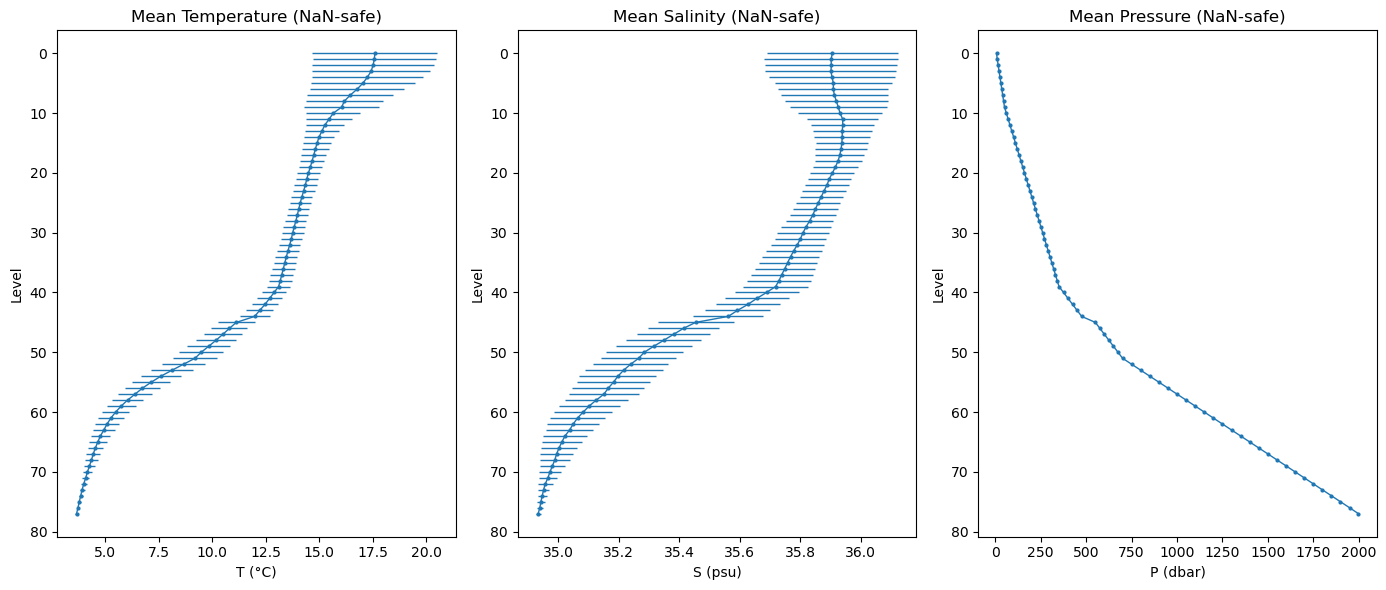

In [14]:
T_mean = np.nanmean(T, axis=1)
T_std  = np.nanstd(T, axis=1)

S_mean = np.nanmean(S, axis=1)
S_std  = np.nanstd(S, axis=1)

P_mean = np.nanmean(P, axis=1)
P_std  = np.nanstd(P, axis=1)

# Now replot with the same errorbar code as 2.5
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

axes[0].errorbar(T_mean, level, xerr=T_std, fmt='-o', markersize=2, linewidth=1)
axes[0].set_title("Mean Temperature (NaN-safe)")
axes[0].set_xlabel("T (°C)")
axes[0].set_ylabel("Level")
axes[0].invert_yaxis()

axes[1].errorbar(S_mean, level, xerr=S_std, fmt='-o', markersize=2, linewidth=1)
axes[1].set_title("Mean Salinity (NaN-safe)")
axes[1].set_xlabel("S (psu)")
axes[1].set_ylabel("Level")
axes[1].invert_yaxis()

axes[2].errorbar(P_mean, level, xerr=P_std, fmt='-o', markersize=2, linewidth=1)
axes[2].set_title("Mean Pressure (NaN-safe)")
axes[2].set_xlabel("P (dbar)")
axes[2].set_ylabel("Level")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

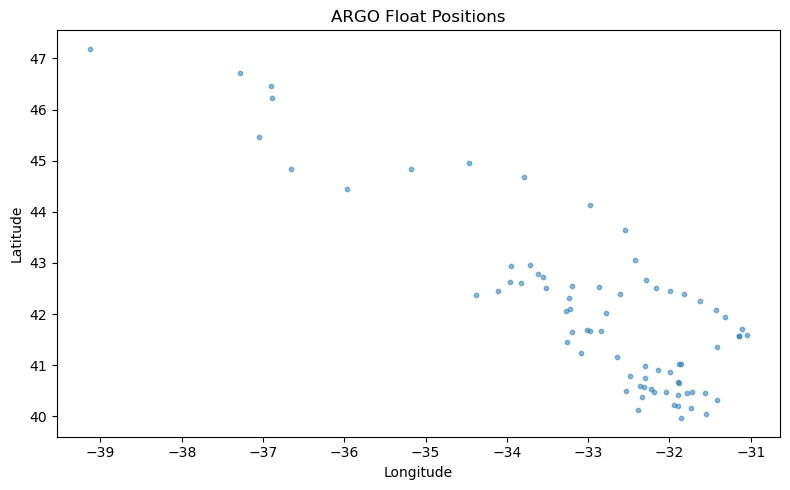

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(lon, lat, s=10, alpha=0.5)
ax.set_title("ARGO Float Positions")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()